In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight

In [2]:
T = 20
dt = 0.5e-3
bat_flight = generate_bat_flight(
    T=T,
    dt=dt,
    speed_correlation_time=5,
    initial_position=[4.5, 4.5, 2],
    initial_heading=[1, 1, 1],
)

100%|██████████| 39999/39999 [00:02<00:00, 16687.35it/s]


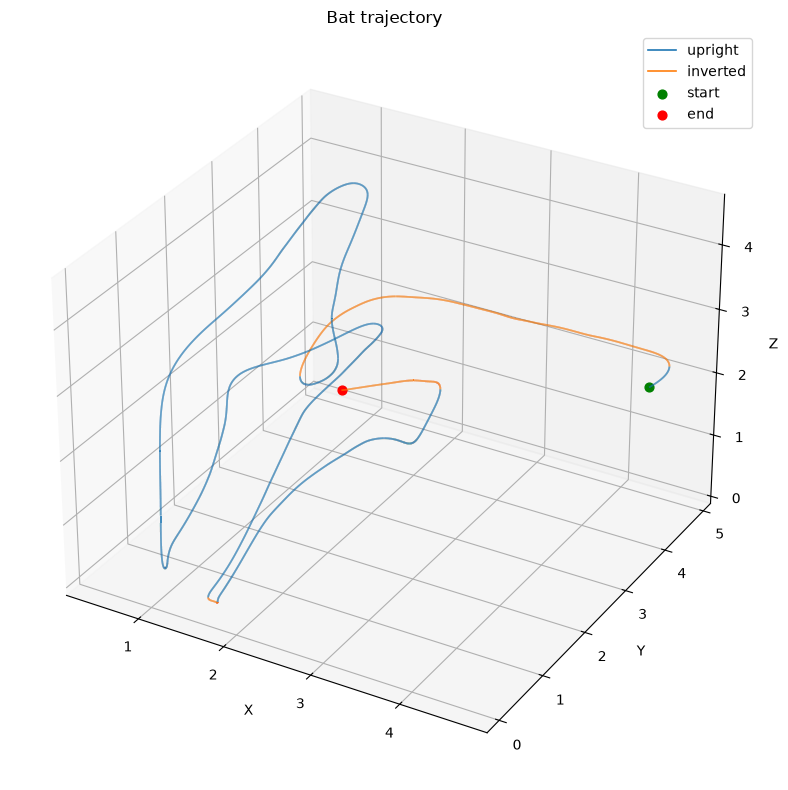

In [3]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

inverting = bat_flight["inverted"]

pos = bat_flight["pos"]
inverted = pos[inverting]
upright = pos[~inverting]


segments = np.stack([pos[:-1], pos[1:]], axis=1)
colors = np.where(inverting[:-1], "tab:orange", "tab:blue")

ax.add_collection3d(Line3DCollection(segments, colors=colors, linewidths=1.2))
# Add legend entries for the trajectory color states
ax.plot([], [], color="tab:blue", lw=1.2, label="upright")
ax.plot([], [], color="tab:orange", lw=1.2, label="inverted")
ax.scatter(pos[0, 0], pos[0, 1], pos[0, 2], color="green", s=40, label="start")
ax.scatter(pos[-1, 0], pos[-1, 1], pos[-1, 2], color="red", s=40, label="end")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Bat trajectory")
ax.legend()
plt.tight_layout()
plt.show()

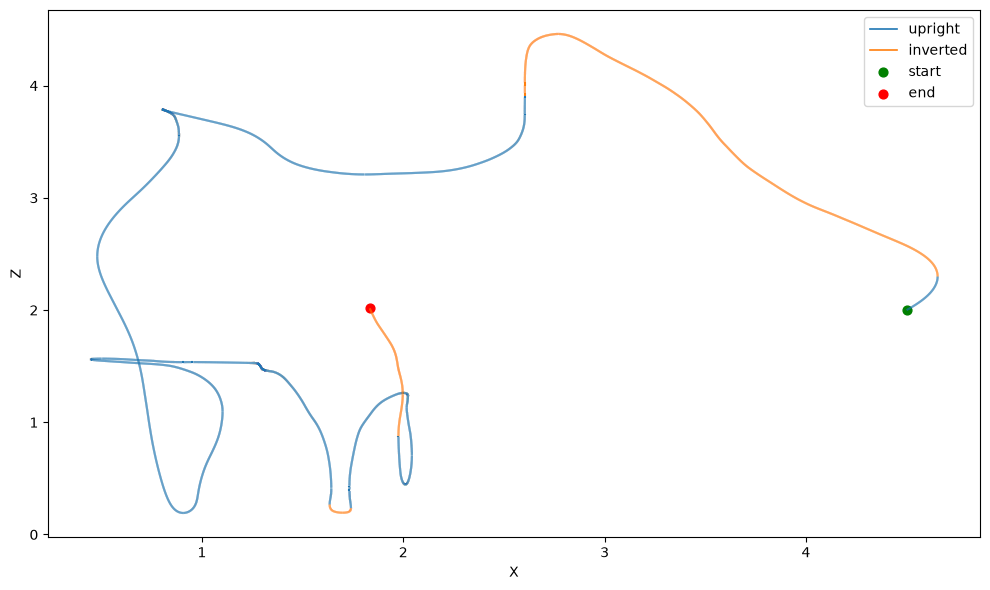

In [4]:
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

fig2, ax2 = plt.subplots(figsize=(10, 6))

dims = [0, 2]

dims_label = ["X", "Y", "Z"]

segments_xz = np.stack([pos[:-1, dims], pos[1:, dims]], axis=1)
colors = np.where(inverting[:-1], "tab:orange", "tab:blue")


ax2.add_collection(LineCollection(segments_xz, colors=colors))
ax2.plot([], [], color="tab:blue", lw=1.2, label="upright")
ax2.plot([], [], color="tab:orange", lw=1.2, label="inverted")


ax2.scatter(pos[0, dims[0]], pos[0, dims[1]], color="green", s=40, label="start")
ax2.scatter(pos[-1, dims[0]], pos[-1, dims[1]], color="red", s=40, label="end")

ax2.set_xlabel(dims_label[dims[0]])
ax2.set_ylabel(dims_label[dims[1]])
ax2.legend(loc="best")
plt.tight_layout()
plt.show()

In [5]:
bat_flight["dir_torus"][0] / np.pi

array([0.25      , 0.19591328])

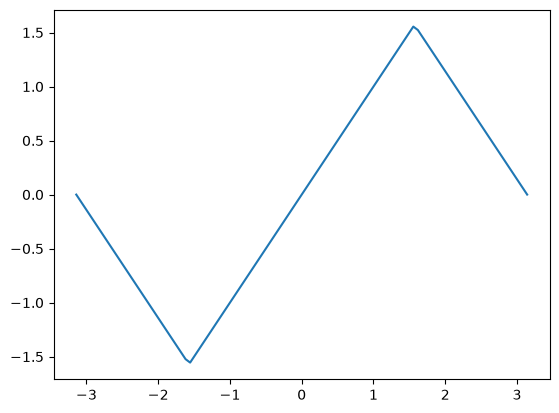

In [6]:
def compute_heading(heading):
    current_azimuth = heading[..., 0]
    current_pitch = heading[..., 1]
    h_x = np.cos(current_pitch) * np.cos(current_azimuth)
    h_y = np.cos(current_pitch) * np.sin(current_azimuth)
    h_z = np.sin(current_pitch)
    current_heading = np.array([h_x, h_y, h_z]).T
    return current_heading


def compute_spherical_coordinates(heading):
    """
    Convert 3D Cartesian heading vector to spherical coordinates (azimuth, pitch).

    Args:
        heading: 3D heading vector or array of heading vectors.

    Returns:
        Array of (azimuth, pitch) angles in radians.
    """
    heading = np.asarray(heading, dtype=float)
    heading_norm = np.linalg.norm(heading, axis=-1, keepdims=True)
    heading = heading / np.clip(heading_norm, 1e-12, None)

    azimuth = np.arctan2(heading[..., 1], heading[..., 0])
    pitch = np.arcsin(np.clip(heading[..., 2], -1.0, 1.0))

    return np.stack((azimuth, pitch), axis=-1)


pitch = np.linspace(-np.pi, np.pi, 100)
azimuth = np.ones_like(pitch) * np.pi

plt.plot(
    pitch,
    compute_spherical_coordinates(
        (compute_heading(np.stack([azimuth, pitch], axis=-1)))
    )[..., 1],
)

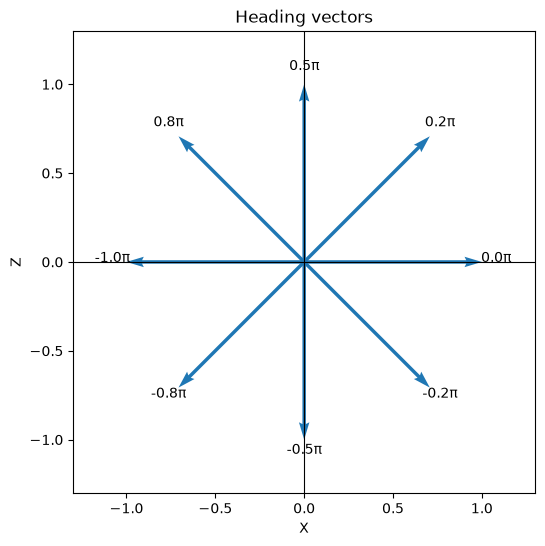

In [7]:
current_pitch = np.linspace(-np.pi, np.pi, 8, endpoint=False)
h_x = np.cos(current_pitch)
h_z = np.sin(current_pitch)
fig, ax = plt.subplots(figsize=(6, 6))

ax.quiver(
    np.zeros_like(h_x),
    np.zeros_like(h_z),
    h_x,
    h_z,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:blue",
)

for angle, x, z in zip(current_pitch, h_x, h_z):
    ax.text(x * 1.08, z * 1.08, f"{angle / np.pi:.1f}π", ha="center")

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect("equal")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_title("Heading vectors")
plt.show()

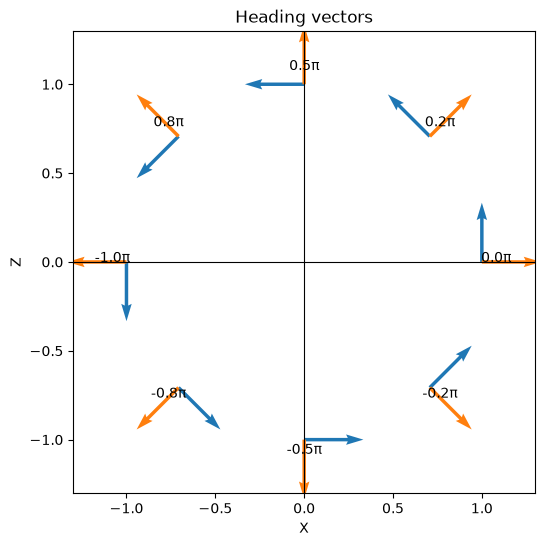

In [8]:
current_pitch = np.linspace(-np.pi, np.pi, 8, endpoint=False)
current_azimuth = 0
h_x = np.cos(current_pitch) * np.cos(current_azimuth)
h_z = np.sin(current_pitch)
u_x = -np.sin(current_pitch) * np.cos(current_azimuth)
u_z = np.cos(current_pitch)
fig, ax = plt.subplots(figsize=(6, 6))

ax.quiver(
    h_x,
    h_z,
    u_x,
    u_z,
    angles="xy",
    scale_units="xy",
    scale=3,
    color="tab:blue",
)
ax.quiver(
    h_x,
    h_z,
    h_x,
    h_z,
    angles="xy",
    scale_units="xy",
    scale=3,
    color="tab:orange",
)


for angle, x, z in zip(current_pitch, h_x, h_z):
    ax.text(x * 1.08, z * 1.08, f"{angle / np.pi:.1f}π", ha="center")

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect("equal")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_title("Heading vectors")
plt.show()